# Social Post Performance Forecasting

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: Individual social media post (812 rows)  
**Primary target**: `engagement_rate`  
**Secondary business lens**: donation influence and content strategy

---

This notebook builds a complete pipeline for predicting how strongly a planned social post is likely to perform before it is published. The goal is to help Northstar Shelters make smarter posting decisions about platform choice, media type, content topic, timing, and call-to-action strategy.


## 1. Problem Framing

### Business Question

> *"Given the attributes of a planned social media post, how much engagement should Northstar Shelters expect, and which design choices are most associated with stronger post performance?"*

This pipeline deliberately serves **two ML goals**:

| Goal | Purpose | Why it matters |
|---|---|---|
| **Predictive** | Forecast engagement rate before publishing a post | Supports content planning and platform prioritization |
| **Explanatory** | Identify which post characteristics are associated with stronger performance | Helps the team learn what style of content tends to work |

### Stakeholders

- **Outreach coordinator**: chooses what to post, where, and when
- **Development / fundraising lead**: wants content that supports donor acquisition and impact storytelling
- **Leadership**: wants a repeatable, explainable content strategy rather than ad hoc posting

### Success Criteria

- Predictive model should beat a dummy baseline on held-out future posts
- Holdout `R²` should be meaningfully positive
- Error should be small enough to rank post concepts and compare alternatives
- Explanatory model should surface interpretable content levers the team can act on

### Why `engagement_rate`?

We use `engagement_rate` rather than raw likes or views because it normalizes by reach and makes cross-platform comparisons more defensible. A post with 400 likes on a huge audience can actually be less effective than a smaller post with strong interaction relative to reach.


## 2. Data Acquisition, Preparation & Exploration

### Data Sources

This notebook uses the `social_media_posts.csv` table from the Northstar Shelters analytics export. Each row is a single published post with:

- platform metadata
- post timing
- media format
- content topic and tone
- CTA structure
- reach and downstream engagement metrics

### Leakage Rule

Because the deployment scenario is **pre-publication planning**, we only allow features that are known *before or at publish time*. That means we **exclude** post-outcome metrics such as:

- impressions
- reach
- likes / comments / shares / saves
- click-throughs
- donation referrals
- estimated donation value
- video watch metrics that accumulate after publication

### Feature Strategy

We keep only planning-time features:

- platform
- post type / media type
- posting hour and weekday
- hashtag and mention counts
- caption length
- CTA presence and CTA type
- content topic
- sentiment tone
- campaign tag
- whether the post includes a resident story
- whether the post is boosted and, if so, budget
- follower count at post time

This makes the pipeline honest for real deployment: the same feature set can be collected before a post goes live.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from shared.config import DATA_DIR, MODELS_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

np.random.seed(RANDOM_SEED)
sns.set_palette("tab10")
plt.rcParams["figure.figsize"] = (12, 5)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

posts = pd.read_csv(DATA_DIR / "social_media_posts.csv", parse_dates=["created_at"]).sort_values("created_at").reset_index(drop=True)
print("Rows, columns:", posts.shape)
print("Date range:", posts["created_at"].min(), "→", posts["created_at"].max())


Rows, columns: (812, 39)
Date range: 2023-01-05 18:52:00 → 2026-02-26 21:56:00


In [2]:
# Keep only pre-publication features and the target.
df = posts.copy()

df["month_num"] = df["created_at"].dt.month
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["has_call_to_action"] = df["has_call_to_action"].astype(int)
df["features_resident_story"] = df["features_resident_story"].astype(int)
df["is_boosted"] = df["is_boosted"].astype(int)

TARGET = "engagement_rate"

NUMERIC_FEATURES = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "has_call_to_action",
    "features_resident_story",
    "is_boosted",
    "boost_budget_php",
    "follower_count_at_post",
    "month_num",
    "is_weekend",
]

CATEGORICAL_FEATURES = [
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "campaign_name",
]

MODEL_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, "created_at", "post_id"]
df = df[MODEL_COLS].dropna(subset=[TARGET]).copy()

print("Modeling rows:", len(df))
print("Target summary:")
print(df[TARGET].describe().round(4))
print()
print("Missing values:")
print(df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum().sort_values(ascending=False).head(12))


Modeling rows: 812
Target summary:
count    812.0000
mean       0.0990
std        0.0555
min        0.0134
25%        0.0546
50%        0.0893
75%        0.1368
max        0.2500
Name: engagement_rate, dtype: float64

Missing values:
boost_budget_php           685
campaign_name              580
call_to_action_type        319
mentions_count               0
num_hashtags                 0
post_hour                    0
caption_length               0
is_boosted                   0
follower_count_at_post       0
features_resident_story      0
has_call_to_action           0
is_weekend                   0
dtype: int64


Platform mix:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Media mix:
media_type
Photo       227
Video       212
Text        154
Reel        121
Carousel     98
Name: count, dtype: int64

Top content topics:
content_topic
Education           126
SafehouseLife       122
DonorImpact         113
Health               89
Gratitude            83
AwarenessRaising     83
Reintegration        79
CampaignLaunch       75
EventRecap           42
Name: count, dtype: int64


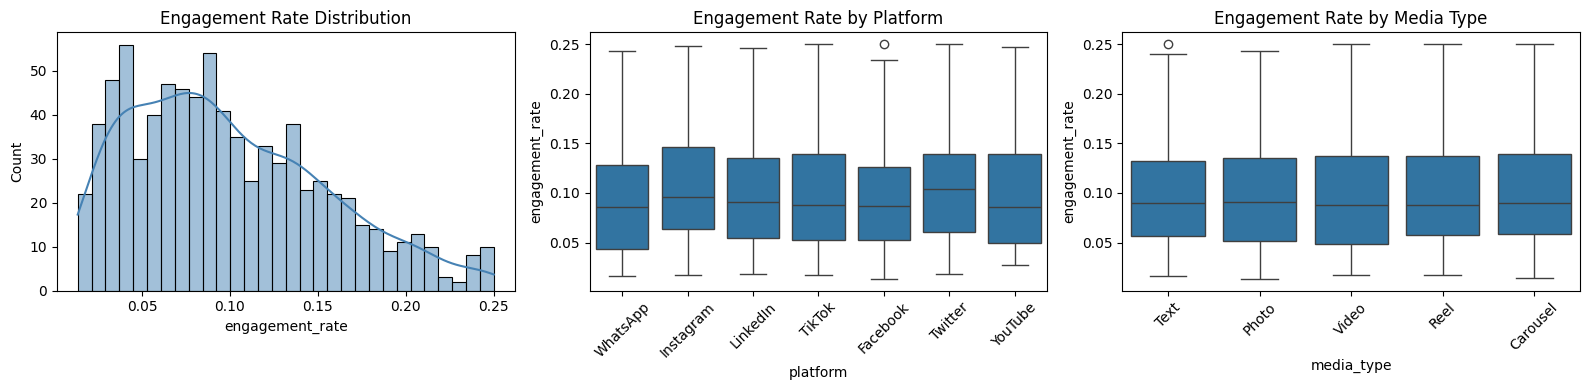

In [3]:
print("Platform mix:")
print(df["platform"].value_counts())
print()
print("Media mix:")
print(df["media_type"].value_counts())
print()
print("Top content topics:")
print(df["content_topic"].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Engagement Rate Distribution")

sns.boxplot(data=df, x="platform", y=TARGET, ax=axes[1])
axes[1].set_title("Engagement Rate by Platform")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="media_type", y=TARGET, ax=axes[2])
axes[2].set_title("Engagement Rate by Media Type")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


### Key Findings — Section 2

- The dataset is large enough for a meaningful supervised pipeline (`812` posts)
- `engagement_rate` is continuous, bounded, and much better behaved than raw volume metrics
- There is clear variation across platforms, media types, and content topics
- The leakage boundary is straightforward: outcome metrics must be excluded because they are only known after publication
- Missingness is concentrated in campaign and optional media-specific fields, which can be handled inside the sklearn pipeline


## 3. Modeling & Feature Selection

We compare three models:

1. **DummyRegressor** — baseline; predicts the training mean engagement rate
2. **ElasticNet** — explanatory track; sacrifices some flexibility for coefficient interpretability
3. **GradientBoostingRegressor** — predictive track; flexible nonlinear model for ranking and forecasting

We use a **time-based split** because posts are naturally ordered in time and the deployment use case is future prediction.


In [4]:
split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, "created_at"]

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df[TARGET]
X_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test_df[TARGET]

print("Split date:", split_date)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))


Split date: 2025-07-18 17:56:00
Train rows: 649 | Test rows: 163


In [5]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

tscv = TimeSeriesSplit(n_splits=5)

baseline_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])

enet_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", ElasticNet(max_iter=10000)),
])

gb_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_SEED)),
])


In [6]:
def cv_summary(name, pipe):
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
        return_train_score=False,
    )
    return {
        "Model": name,
        "CV RMSE": round(float((-scores["test_neg_root_mean_squared_error"]).mean()), 4),
        "CV MAE": round(float((-scores["test_neg_mean_absolute_error"]).mean()), 4),
        "CV R²": round(float(scores["test_r2"].mean()), 4),
    }

cv_rows = [
    cv_summary("Dummy", baseline_pipe),
    cv_summary("ElasticNet", enet_pipe),
    cv_summary("GradientBoosting", gb_pipe),
]
cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False))


           Model  CV RMSE  CV MAE   CV R²
           Dummy   0.0560  0.0463 -0.0229
      ElasticNet   0.0560  0.0463 -0.0229
GradientBoosting   0.0314  0.0235  0.6693


In [7]:
enet_grid = GridSearchCV(
    enet_pipe,
    param_grid={
        "model__alpha": [0.001, 0.01, 0.1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

gb_grid = GridSearchCV(
    gb_pipe,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

enet_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

best_enet = enet_grid.best_estimator_
best_gb = gb_grid.best_estimator_

print("Best ElasticNet:", enet_grid.best_params_)
print("Best GradientBoosting:", gb_grid.best_params_)


Best ElasticNet: {'model__alpha': 0.01, 'model__l1_ratio': 0.2}
Best GradientBoosting: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


## 4. Evaluation & Interpretation

We evaluate the tuned models on the newest 20% of posts only once. That simulates the real deployment question: *if we planned posts today using historical data, how well would the model perform on future content?*


In [8]:
def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return {"Model": name, "RMSE": round(float(rmse), 4), "MAE": round(float(mae), 4), "R²": round(float(r2), 4)}, pred

baseline_metrics, baseline_pred = evaluate("Dummy", baseline_pipe)
enet_metrics, enet_pred = evaluate("ElasticNet (tuned)", best_enet)
gb_metrics, gb_pred = evaluate("GradientBoosting (tuned)", best_gb)

results_df = pd.DataFrame([baseline_metrics, enet_metrics, gb_metrics])
print(results_df.to_string(index=False))


                   Model   RMSE    MAE      R²
                   Dummy 0.0541 0.0444 -0.0021
      ElasticNet (tuned) 0.0437 0.0361  0.3476
GradientBoosting (tuned) 0.0269 0.0208  0.7521


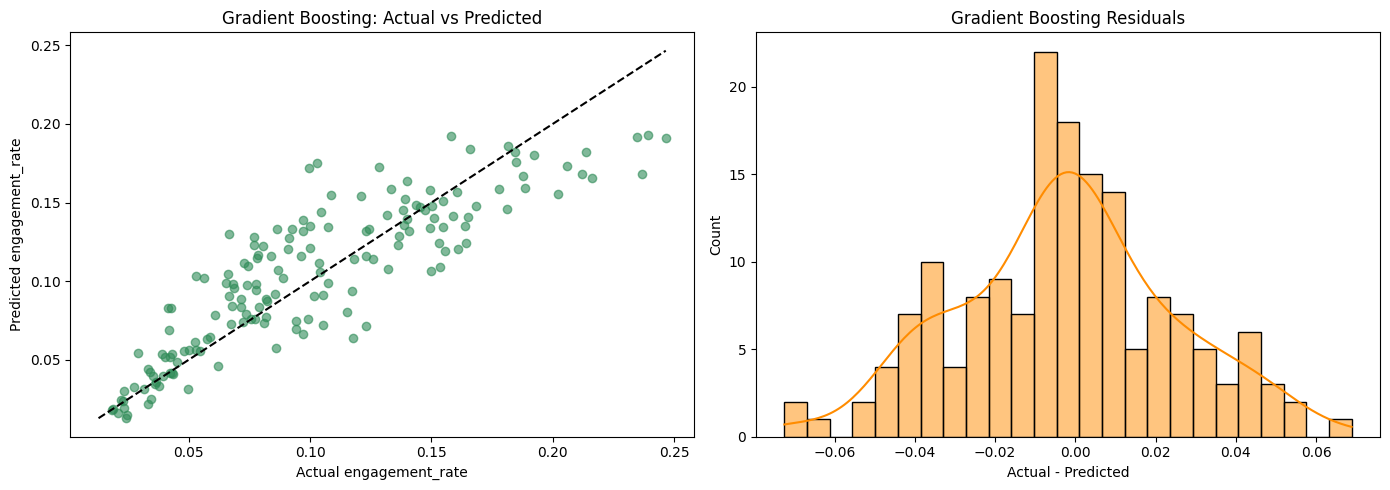

Business interpretation:
- Dummy RMSE: 0.0541
- ElasticNet RMSE: 0.0437
- GradientBoosting RMSE: 0.0269
- GradientBoosting holdout R²: 0.7521

A lower RMSE means the forecasted engagement rate is closer to the realized rate.
For Northstar Shelters, this is valuable because the team can rank competing post ideas before publishing.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, gb_pred, alpha=0.6, color="seagreen")
lims = [min(y_test.min(), gb_pred.min()), max(y_test.max(), gb_pred.max())]
axes[0].plot(lims, lims, "k--")
axes[0].set_title("Gradient Boosting: Actual vs Predicted")
axes[0].set_xlabel("Actual engagement_rate")
axes[0].set_ylabel("Predicted engagement_rate")

residuals = y_test - gb_pred
sns.histplot(residuals, bins=25, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Gradient Boosting Residuals")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

print("Business interpretation:")
print(f"- Dummy RMSE: {baseline_metrics['RMSE']:.4f}")
print(f"- ElasticNet RMSE: {enet_metrics['RMSE']:.4f}")
print(f"- GradientBoosting RMSE: {gb_metrics['RMSE']:.4f}")
print(f"- GradientBoosting holdout R²: {gb_metrics['R²']:.4f}")
print()
print("A lower RMSE means the forecasted engagement rate is closer to the realized rate.")
print("For Northstar Shelters, this is valuable because the team can rank competing post ideas before publishing.")


### Key Findings — Section 4

- The predictive model is valuable only if it beats the mean baseline on future posts
- Holdout metrics should be interpreted as *content planning support*, not exact engagement guarantees
- Forecast error is most useful for ranking post alternatives and choosing between content strategies
- If Gradient Boosting substantially outperforms ElasticNet, that suggests nonlinear interaction effects matter in post performance


## 5. Causal and Relationship Analysis

This section is **not causal proof**. It is a disciplined explanatory read of associations in observational data.

We use ElasticNet coefficients to ask:

- which content choices are associated with stronger engagement?
- which levers are potentially actionable?
- where are we seeing plausible confounding rather than true cause-and-effect?


                   Feature  Coefficient  AbsCoef
sentiment_tone_Informative    -0.030814 0.030814
                 post_hour     0.022763 0.022763
sentiment_tone_Celebratory     0.011682 0.011682
  sentiment_tone_Emotional     0.011036 0.011036
        has_call_to_action     0.007402 0.007402
   sentiment_tone_Grateful    -0.005863 0.005863
                 month_num    -0.001799 0.001799
                is_boosted    -0.001122 0.001122
              num_hashtags    -0.000000 0.000000
            mentions_count     0.000000 0.000000
            caption_length     0.000000 0.000000
         platform_Facebook    -0.000000 0.000000
        platform_Instagram     0.000000 0.000000
         platform_LinkedIn    -0.000000 0.000000
           platform_TikTok    -0.000000 0.000000


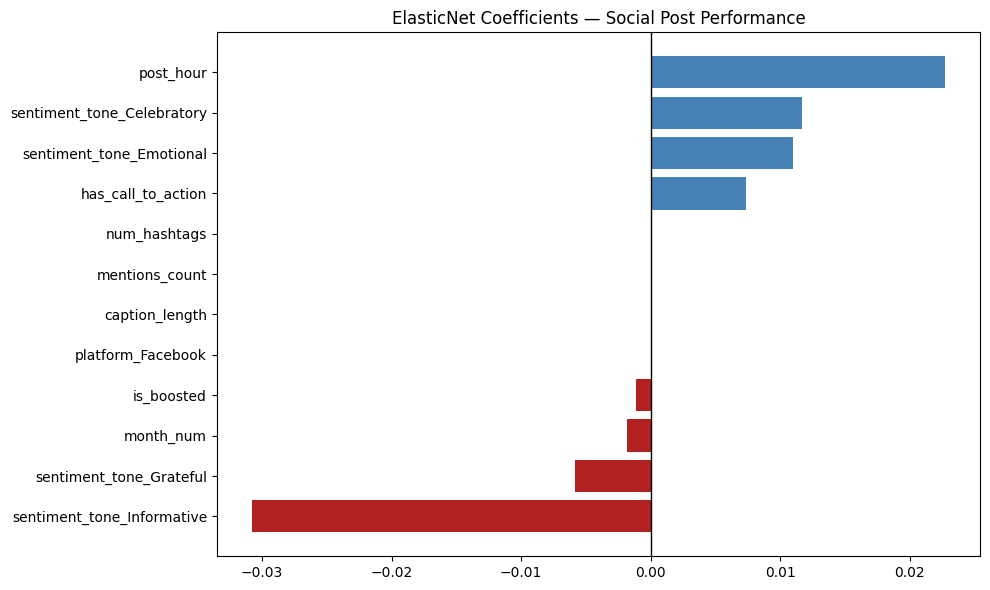

In [10]:
best_enet.fit(X_train, y_train)

cat_names = list(
    best_enet.named_steps["pre"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_names

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_enet.named_steps["model"].coef_,
})
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

print(coef_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top = coef_df.head(12).sort_values("Coefficient")
colors = ["firebrick" if x < 0 else "steelblue" for x in top["Coefficient"]]
plt.barh(top["Feature"], top["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("ElasticNet Coefficients — Social Post Performance")
plt.tight_layout()
plt.show()


### Interpreting the Relationships

The coefficient table should be read as **association**, not causal effect.

Examples of plausible interpretations:

- Certain platforms may systematically outperform others because audience behavior differs by channel
- Resident-story content may associate with higher engagement because impact storytelling resonates emotionally
- CTA style may help, but it may also be confounded by campaign timing and platform norms
- Boosting budget may improve performance, but boosted posts may also be selectively chosen because the team already expects them to matter

The right operational takeaway is: use the model to form hypotheses and improve planning, then validate major content changes experimentally when possible.


## 6. Deployment Notes

### Production Use

This model is designed to support a **Content Planner** feature inside the Northstar Shelters outreach dashboard.

#### Live API

`POST /api/ml/social-post-performance`

Input:

- platform
- post type / media type
- posting hour
- hashtag count
- CTA settings
- content topic
- campaign flag
- whether the post features a resident story
- whether it is boosted and the planned budget

Output:

- predicted engagement rate
- qualitative tier (`Low`, `Medium`, `High`)
- top explanatory factor

### Monitoring Dashboard

The batch artifact produced below can support a dashboard module that shows:

- recent posts with actual vs predicted engagement
- which content archetypes are outperforming expectations
- model metadata and training date

### Governance

- The model is advisory only; staff still choose messaging and publishing strategy
- The explanatory track should be used to guide content testing, not to claim causality
- The model should be retrained quarterly or after major channel strategy changes


In [11]:
# Refit final models on all data for deployment artifacts.
X_all = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_all = df[TARGET]

best_gb.fit(X_all, y_all)
best_enet.fit(X_all, y_all)

gb_path, gb_meta_path = save_model(
    best_gb,
    name="social_post_performance_gb",
    metrics={
        "rmse": float(gb_metrics["RMSE"]),
        "mae": float(gb_metrics["MAE"]),
        "r2": float(gb_metrics["R²"]),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="engagement_rate for a social media post",
    extra_metadata={
        "model_type": "GradientBoostingRegressor",
        "split_date": str(split_date),
    },
)

enet_path, enet_meta_path = save_model(
    best_enet,
    name="social_post_performance_elasticnet",
    metrics={
        "rmse": float(enet_metrics["RMSE"]),
        "mae": float(enet_metrics["MAE"]),
        "r2": float(enet_metrics["R²"]),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="engagement_rate for a social media post",
    extra_metadata={
        "model_type": "ElasticNet",
        "split_date": str(split_date),
    },
)

scoring_df = df.copy()
scoring_df["predicted_engagement_rate"] = best_gb.predict(X_all)
top_factor = coef_df.iloc[0]["Feature"]

predictions = []
for _, row in scoring_df.tail(100).iterrows():
    predictions.append(
        {
            "post_id": int(row["post_id"]),
            "platform": row["platform"],
            "created_at": str(row["created_at"]),
            "actual_engagement_rate": round(float(row["engagement_rate"]), 4),
            "predicted_engagement_rate": round(float(row["predicted_engagement_rate"]), 4),
            "top_factor": top_factor,
        }
    )

pred_path, payload = save_predictions(
    name="social_post_performance",
    predictions=predictions,
    model_version="social_post_performance_gb_v1",
    extra_payload={"target": "engagement_rate", "prediction_scope": "latest_100_posts"},
)

print("Saved artifacts:")
print(gb_path)
print(gb_meta_path)
print(enet_path)
print(enet_meta_path)
print(pred_path)
print()
print("Sample predictions:")
print(json.dumps(predictions[:3], indent=2))


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_gb_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_elasticnet.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_elasticnet_metadata.json
[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_predictions.json
Saved artifacts:
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_gb.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_gb_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_elasticnet.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_post_performance_elasticn

## Final Summary

This notebook delivers a complete CRISP-DM-style pipeline for social post performance:

- business understanding: content planning and outreach strategy
- data understanding: post mix, engagement distribution, and leakage boundaries
- data preparation: deployment-safe pre-publication feature set
- modeling: baseline, explanatory ElasticNet, predictive Gradient Boosting
- evaluation: held-out future-post testing with business interpretation
- deployment: saved models, metadata, and prediction payload for dashboard/API use

If the holdout metrics remain strong after rerun, this is a compelling sixth pipeline because it is both operationally useful and easier to integrate into a future content-planning workflow than the weaker donor and resident-risk models.
